<center>
    <h1>ĐỀ TÀI: XÂY DỰNG MÔ HÌNH PHÂN LOẠI Ý ĐỊNH ĐỂ PHÁT TRIỂN CHATBOT FAQ VỀ QUY CHẾ ĐÀO TẠO TRƯỜNG ĐẠI HỌC MỎ - ĐỊA CHẤT</h1>
 </center>

 **Thông tin sinh viên:**
Đồng Ngọc Phúc - 2221050279

## 1. Tiếp cận vấn đề và xác định bài toán

Mục tiêu của đề tài là tạo ra chatbot trả lời các câu hỏi về quy chế mà người dùng đặt ra. Vì vậy ta phải xác định được các bài toán đặt ra để đạt được mục tiêu này:
1. Xác định nguồn dữ liệu để xây dựng tập dữ liệu cho mô hình (File PDF quy chế đào tạo 768 trên trang web chính thức của trường Đại học Mỏ - Địa chất)
2. Trích xuất các thông tin mà sinh viên hay quan tâm và chuẩn hóa lại dữ liệu thành dạng dữ liệu có cấu trúc để tiếp tục tiến đến các bước tiếp theo (Do file PDF là dạng dữ liệu phi cấu trúc)
3. Xử lý dữ liệu làm sao cho máy hiểu được.
4. Huấn luyện mô hình với đầu vào là các dữ liệu đã xử lý được.
5. Kiểm thử và đánh giá độ chính xác của mô hình.
6. Kết luận và đưa ra các biện pháp để cải thiện độ chính xác
7. Triển khai mô hình

## 2. Xây dựng tập dữ liệu

Do file PDF là dạng dữ liệu phi cấu trúc, rất khó để xử lý thông qua việc lập trình và vốn dĩ đề tài chỉ tập trung vào các vấn đề mà sinh viên hay thắc mắc. Nên để cho công việc dễ dàng hơn, ta sẽ chuẩn hóa dữ liệu thành file JSON có cấu trúc như sau:

Mảng intents: Chứa danh sách tất cả các chủ đề/ý định (Intents) mà người dùng có thể hỏi.

Mỗi phần tử trong mảng "intents" là một đối tượng (Object) đại diện cho một chủ đề cụ thể (ví dụ: Quy định về Tốt nghiệp, Quy định về Tính điểm), và có 3 trường dữ liệu chính:

-- tag (nhãn): Mã định danh duy nhất cho ý định hoặc chủ đề đó.

-- patterns (mẫu câu): Chứa danh sách các câu hỏi mẫu hay các cách diễn đạt khác nhau của người dùng về chủ đề đó.

-- responses: Chứa nội dung câu trả lời chi tiết và chính thức cho ý định (tag) tương ứng. Đây là nội dung mà bot sẽ trả lời người dùng.

In [1]:
# Cài đặt các thư viện cần thiết
# %pip install scikit-learn pyvi joblib pandas matplotlib
# pyvi: Để tách từ tiếng Việt
# scikit-learn: Để huấn luyện mô hình
# pandas, matplotlib: Để trực quan hóa dữ liệu
# joblib: Để lưu mô hình đã huấn luyện

In [2]:
import json

# Đọc file dữ liệu
DATA_PATH = 'data/data_daotao.json'

with open(DATA_PATH, 'r', encoding='utf-8') as f:
    raw_data = json.load(f)

# Kiểm tra thử xem đọc được chưa bằng cách in ra 1 intent đầu tiên
print("Mẫu dữ liệu đầu tiên:", raw_data['intents'][0])

Mẫu dữ liệu đầu tiên: {'tag': 'cac_dot_dang_ky_hoc_phan', 'patterns': ['Có mấy đợt đăng ký học phần?', 'Đăng ký lớp đợt 1 là khi nào?', 'Đợt 2 đăng ký học phần thời gian thế nào?', 'Đợt đăng ký bổ sung là gì?', 'Học kỳ phụ có đợt đăng ký bổ sung không?', 'Em muốn biết thời gian các đợt đăng ký môn học', 'Đăng ký môn trên daotao.humg.edu.vn như thế nào?', 'Khi nào là thời điểm điều chỉnh kế hoạch học tập?', 'Đợt đăng ký chính thức diễn ra vào lúc nào?', 'Thời hạn cuối cùng để đăng ký bổ sung là khi nào?', 'Đăng ký học phần được chia thành bao nhiêu giai đoạn?', 'Chi tiết thời gian của đợt 1, đợt 2, đợt 3 đăng ký học phần', 'Tôi có thể đăng ký môn học ở đâu?', 'Thời điểm nào là đăng ký lớp chính thức?', 'Đợt đăng ký bổ sung có áp dụng cho học kỳ hè không?', 'Đợt đăng ký học phần cuối cùng là đợt nào?', 'Làm thế nào để điều chỉnh thời khóa biểu sau đợt 2?', 'Khi nào đợt 1 kết thúc?', 'Quy trình đăng ký môn học trên hệ thống daotao.humg.edu.vn', 'Đợt điều chỉnh kế hoạch học tập kéo dài bao

## 3. Tiền xử lý và xử lý dữ liệu

Do khi nhận câu hỏi từ người dùng, ta cũng cần phải xử lý các dữ liệu đầu vào đó nên ta sẽ xây dựng các hàm dành cho các bước tiền xử lý để tái sử dụng sau này

### Đưa mọi ký tự về dạng viết thường để đảm bảo tính nhất quán

In [3]:
def step1_lowercase(text):
    return text.lower() 

### Tách từ

Tách từ (Tokenization) là kỹ thuật giúp máy tính xác định đâu là một từ có nghĩa trọn vẹn trong câu, thay vì chỉ cắt câu dựa trên các dấu cách (khoảng trắng).

Đây là bước quan trọng nhất khi xử lý Tiếng Việt vì đặc thù ngôn ngữ của chúng ta khác với tiếng Anh.

- Tiếng Anh: Đa phần các từ được phân tách nhau bằng dấu cách.Ví dụ: "I love football" $\rightarrow$ Máy cắt ngay được 3 từ: ["I", "love", "football"].

- Tiếng Việt: Dấu cách dùng để tách âm tiết (tiếng), không phải tách từ. Từ trong tiếng Việt có thể là từ đơn (1 chữ) hoặc từ ghép (2, 3, 4 chữ).

Ví dụ: "sinh viên", "đất nước", "nhà máy điện".Nếu máy tính chỉ cắt dựa trên dấu cách, nó sẽ hiểu sai nghĩa nghiêm trọng.

In [4]:
from pyvi import ViTokenizer  # Thư viện tách từ tiếng Việt
def step2_tokenize(text):
    return ViTokenizer.tokenize(text)

### Định nghĩa danh sách Stopwords

StopWords là những từ xuất hiện nhiều trong ngôn ngữ tự nhiên, tuy nhiên lại không mang nhiều ý nghĩa. Ở tiếng việt StopWords là những từ như: để, này, kia...

Do các thư viện về xử lý ngôn ngữ Tiếng Việt chưa được phổ biến và mạnh mẽ, cộng thêm việc quy mô của đề tài không quá lớn. Việc tạo sẵn các danh sách Stopwords sẽ đủ tốt và dễ kiểm soát hơn.

In [ ]:
vietnamese_stopwords = set([
    "là", "của", "các", "những", "cho", "với", "thì", "mà", "bị", "bởi", "được", "tại", "vì", "rằng", 
    "em", "muốn", "biết", "ạ", "ơi", "hỏi", "về", "như", "này", "khi", "trong", "để", "làm", "gì", 
    "nào", "ở", "có", "không", "nhưng", "rất", "cũng", "đã", "sẽ", "đang", "vẫn", "cứ", "chỉ", 
    "nếu", "hoặc", "hay", "do", "nên", "nữa", "đâu", "đấy", "đây", "rồi", "chi", "nhiêu", 
    "để", "này", "kia"
])
def step3_remove_stopwords(text, stopwords = vietnamese_stopwords):
    # Tách chuỗi thành danh sách các từ
    words = text.split()
    # Lọc bỏ từ nằm trong danh sách stopwords
    filtered_words = [w for w in words if w not in stopwords]
    # Ghép lại thành chuỗi
    return " ".join(filtered_words)

### Tạo pipeline để tổng hợp các bước trên

In [6]:
def processing_pipeline(text):
    if not text: return ""
    
    text = step1_lowercase(text)
    text = step2_tokenize(text)
    text = step3_remove_stopwords(text)
    return text

### Áp dụng vào dữ liệu huấn luyện

In [7]:
import pandas as pd  # Thư viện xử lý bảng dữ liệu
corpus = []  # Chứa câu hỏi đã xử lý
labels = []  # Chứa nhãn (Intent)

# Duyệt qua dữ liệu JSON
for intent in raw_data['intents']:
    for pattern in intent['patterns']:
        
        # Gọi hàm tổng hợp để xử lý từng câu mẫu
        cleaned_text = processing_pipeline(pattern)
        
        # Chỉ thêm vào nếu câu không bị rỗng sau khi lọc
        if cleaned_text:
            corpus.append(cleaned_text)
            labels.append(intent['tag'])

# Tạo DataFrame
df = pd.DataFrame({'text': corpus, 'intent': labels})

print("Dữ liệu sau khi qua các bước xử lý riêng biệt:")
display(df.head(10))

Dữ liệu sau khi qua các bước xử lý riêng biệt:


,text,intent
0,mấy đợt đăng_ký học_phần ?,cac_dot_dang_ky_hoc_phan
1,đăng_ký lớp đợt 1 ?,cac_dot_dang_ky_hoc_phan
2,đợt 2 đăng_ký học_phần thời_gian thế_nào ?,cac_dot_dang_ky_hoc_phan
3,đợt đăng_ký bổ_sung ?,cac_dot_dang_ky_hoc_phan
4,học_kỳ phụ đợt đăng_ký bổ_sung ?,cac_dot_dang_ky_hoc_phan
5,thời_gian đợt đăng_ký môn_học,cac_dot_dang_ky_hoc_phan
6,đăng_ký môn trên daotao . humg . edu . vn thế_...,cac_dot_dang_ky_hoc_phan
7,thời_điểm điều_chỉnh kế_hoạch học_tập ?,cac_dot_dang_ky_hoc_phan
8,đợt đăng_ký chính_thức diễn ra vào lúc_nào ?,cac_dot_dang_ky_hoc_phan
9,thời_hạn cuối_cùng đăng_ký bổ_sung ?,cac_dot_dang_ky_hoc_phan


In [8]:
# In thống kê số lượng cụ thể
print("Thống kê số lượng mẫu câu:")
print(df['intent'].value_counts())

Thống kê số lượng mẫu câu:
intent
dieu_kien_xet_tot_nghiep          31
cac_dot_dang_ky_hoc_phan          30
xep_hang_hoc_tap                  30
thuc_tap_do_an_tot_nghiep         30
chuyen_nganh_chuyen_doi           30
bao_luu_thoi_hoc                  30
khoi_luong_hoc_tap                29
danh_gia_tinh_diem_hoc_phan       29
dang_ky_hoc_lai                   29
canh_bao_hoc_tap_buoc_thoi_hoc    29
Name: count, dtype: int64


### Tách dữ liệu thành tập Train - Test

In [9]:
from sklearn.model_selection import train_test_split

# Chia dữ liệu: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    df['text'],    # Đầu vào (câu hỏi)
    df['intent'],  # Đầu ra (nhãn)
    test_size=0.2, # 20% để test
    random_state=42 # Giữ cố định cách chia để kết quả giống nhau mỗi lần chạy
)

print(f"Số câu để huấn luyện: {len(X_train)}")
print(f"Số câu để kiểm thử: {len(X_test)}")
print(y_test.value_counts())

Số câu để huấn luyện: 237
Số câu để kiểm thử: 60
intent
dang_ky_hoc_lai                   9
canh_bao_hoc_tap_buoc_thoi_hoc    8
xep_hang_hoc_tap                  7
chuyen_nganh_chuyen_doi           7
dieu_kien_xet_tot_nghiep          7
cac_dot_dang_ky_hoc_phan          7
thuc_tap_do_an_tot_nghiep         5
khoi_luong_hoc_tap                4
danh_gia_tinh_diem_hoc_phan       3
bao_luu_thoi_hoc                  3
Name: count, dtype: int64


### Sử dụng TF-IDF để mã hóa dữ liệu

TF-IDF (viết tắt của Term Frequency - Inverse Document Frequency) là một kỹ thuật thống kê giúp máy tính đánh giá mức độ quan trọng của một từ trong một văn bản. 

Máy tính không hiểu chữ viết, nó chỉ hiểu các con số. TF-IDF chính là công cụ giúp biến chữ thành số (vector hóa), nhưng thông minh hơn cách đếm từ thông thường.

TF-IDF được ghép bởi 2 thành phần:

1. TF (Term Frequency - Tần suất xuất hiện): Đo lường tần suất một từ xuất hiện trong một câu cụ thể.

    TF(t, d) = (số lần từ t xuất hiện trong văn bản d) / (tổng số từ trong văn bản d)

    Ý nghĩa: Từ xuất hiện càng nhiều trong câu đó thì càng quan trọng đối với câu đó.

    Ví dụ: Trong câu "Học phí này là học phí kỳ 1", từ "học phí" xuất hiện 2 lần $\rightarrow$ TF cao.

2. IDF (Inverse Document Frequency - Nghịch đảo tần suất văn bản) : Đo lường mức độ phổ biến của từ đó trong toàn bộ dữ liệu (tất cả các câu mẫu).
    
    IDF(t, D) = log_e( Tổng số văn bản trong tập mẫu D/ Số văn bản có chứa từ t )

    Ý nghĩa: Từ nào xuất hiện ở quá nhiều câu (như "là", "thì", "mà") thì giá trị IDF sẽ thấp (gần bằng 0). Từ nào chỉ xuất hiện ở một nhóm câu nhất định thì IDF sẽ cao.$$\text{Điểm TF-IDF} = \text{TF} \times \text{IDF}$$

    * Nếu TF cao (xuất hiện nhiều trong tag đang xét) VÀ IDF cao (hiếm gặp ở tag khác) => Điểm TF-IDF rất cao (Từ khóa vàng).
    * Nếu TF cao (xuất hiện nhiều) NHƯNG IDF thấp (từ này tag nào cũng có) => Điểm TF-IDF thấp (Từ phổ thông/Stopword).

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer
# Khởi tạo TF-IDF
vectorizer = TfidfVectorizer()

# 1. Học từ vựng từ tập Train và biến nó thành số
# fit: Học từ vựng (tạo từ điển)
# transform: Biến đổi chữ thành số
X_train_vec = vectorizer.fit_transform(X_train)

# 2. Chỉ biến đổi tập Test thành số (Dùng từ điển đã học ở trên)
X_test_vec = vectorizer.transform(X_test)

print(f"Kích thước dữ liệu số hóa: {X_train_vec.shape}")  # (Số câu, Số lượng từ vựng máy đã học được)

Kích thước dữ liệu số hóa: (237, 312)


## 4. Bắt đầu huấn luyện

### Huấn luyện mô hình (Sử dụng Naive Bayes)

Định lý Bayes giúp chúng ta tính xác suất xảy ra sự kiện A khi biết sự kiện B đã xảy ra:$$P(A|B) = \frac{P(B|A) \times P(A)}{P(B)}$$Áp dụng vào Chatbot:

A: Là chủ đề (Intent), ví dụ: hoc_phi.

B: Là câu người dùng nhập, ví dụ: "học phí bao nhiêu". Ta cần tính: Xác suất câu này là hỏi về hoc_phi (A) nến thấy xuất hiện các từ "học", "phí", "bao", "nhiêu" (B).$$P(\text{Intent}|\text{Từ}) = \frac{P(\text{Từ}|\text{Intent}) \times P(\text{Intent})}{P(\text{Từ})}$$Trong đó: 

$P(\text{Intent})$: Xác suất chung của chủ đề đó (Ví dụ: trong 100 câu mẫu, có 30 câu là hỏi học phí $\rightarrow$ 30%).

$P(\text{Từ}|\text{Intent})$: Nếu chủ đề là hoc_phi, thì xác suất xuất hiện từ "tiền" là bao nhiêu? (Máy sẽ đếm trong dữ liệu huấn luyện).

Trong thư viện Scikit-learn, có 3 loại Naive Bayes chính:

GaussianNB: Dùng cho dữ liệu là số thực liên tục (ví dụ: chiều cao, cân nặng).

BernoulliNB: Dùng cho dữ liệu nhị phân (có/không).

MultinomialNB: Dùng cho dữ liệu dạng đếm số lượng (tần suất).

Vì chúng ta dùng TF-IDF (bản chất là đếm tần suất từ xuất hiện), nên MultinomialNB là sự lựa chọn chuẩn nhất cho xử lý văn bản.

In [11]:
from sklearn.naive_bayes import MultinomialNB
model = MultinomialNB()
#Danh sách các tham số của model:
MultinomialNB().get_params()

{'alpha': 1.0, 'class_prior': None, 'fit_prior': True, 'force_alpha': True}

Trong hàm MultinomialNB(), có 2 tham số chính ta cần quan tâm để áp dụng vào bài toán này:

alpha (Tham số làm trơn): Cộng thêm một con số nhỏ vào tần suất của mọi từ để đảm bảo không có từ nào có xác suất bằng 0. Trong phép nhân, nếu một thành phần bằng 0 thì toàn bộ kết quả bằng 0. Máy sẽ bị lỗi hoặc dự đoán sai. =1 tức là mỗi từ vựng đều được xuất hiện ít nhất 1 lần

fit_prior (Học xác suất ưu tiên): Cho phép máy tự học xem chủ đề (Intent) nào phổ biến hơn.

class_prior (Gán cứng độ phổ biến): Dùng để ép buộc máy phải tin vào một tỷ lệ xác suất do ta tự bịa ra, thay vì học từ dữ liệu. = False tức là mọi chủ đề đều có xs khởi điểm = nhau

force_alpha (Kỹ thuật): Nếu alpha về một số cực nhỏ (gần bằng 0), máy tính có thể gặp lỗi làm tròn số. =True để tránh lỗi

In [12]:
# Đưa dữ liệu số hóa (X_train_vec) và đáp án (y_train) vào để máy học
model.fit(X_train_vec, y_train) 

MultinomialNB()

## 5. Đánh giá mô hình

### Accuracy

Là tỷ lệ các mẫu dự đoán đúng so với tổng số mẫu trong tập.

In [13]:
from sklearn.metrics import accuracy_score
# Dự đoán thử trên tập Test (20% dữ liệu đã giấu)
y_pred_nb = model.predict(X_test_vec)

acc_nb = accuracy_score(y_test, y_pred_nb)
#y_test: danh sách các nhãn đúng của 20% dữ liệu đã "cất đi" lúc chia train_test_split.

print(f"Độ chính xác của mô hình trên tập Test: {acc_nb*100:.2f}%")

acc_nb2 = accuracy_score(y_test, y_pred_nb, normalize=False)
print('Tổng số mẫu dự đoán đúng:', acc_nb2, ' /', len(y_test))
print('Tổng số mẫu dự đoán sai:', len(y_test) - acc_nb2, ' /', len(y_test))

Độ chính xác của mô hình trên tập Test: 81.67%
Tổng số mẫu dự đoán đúng: 49.0  / 60
Tổng số mẫu dự đoán sai: 11.0  / 60


### Confusion Matrix

Confusion Matrix (Ma trận Nhầm lẫn) là một bảng báo cáo chi tiết giúp ta "bắt bệnh" cho Chatbot. Nó cho ta biết chính xác model đang bị nhầm lẫn ở đâu, chứ không chỉ đưa ra một con số điểm tổng quát.


Cấu trúc của Ma trận

Hàng ngang (Rows): Là nhãn Thực tế (Người dùng thực sự hỏi gì).

Cột dọc (Columns): Là nhãn Máy đoán (Bot nghĩ là cái gì).

Mục tiêu: Chúng ta muốn các con số lớn nhất đều nằm trên Đường chéo chính (từ góc trên trái xuống góc dưới phải). Đó là những lần Bot đoán đúng.

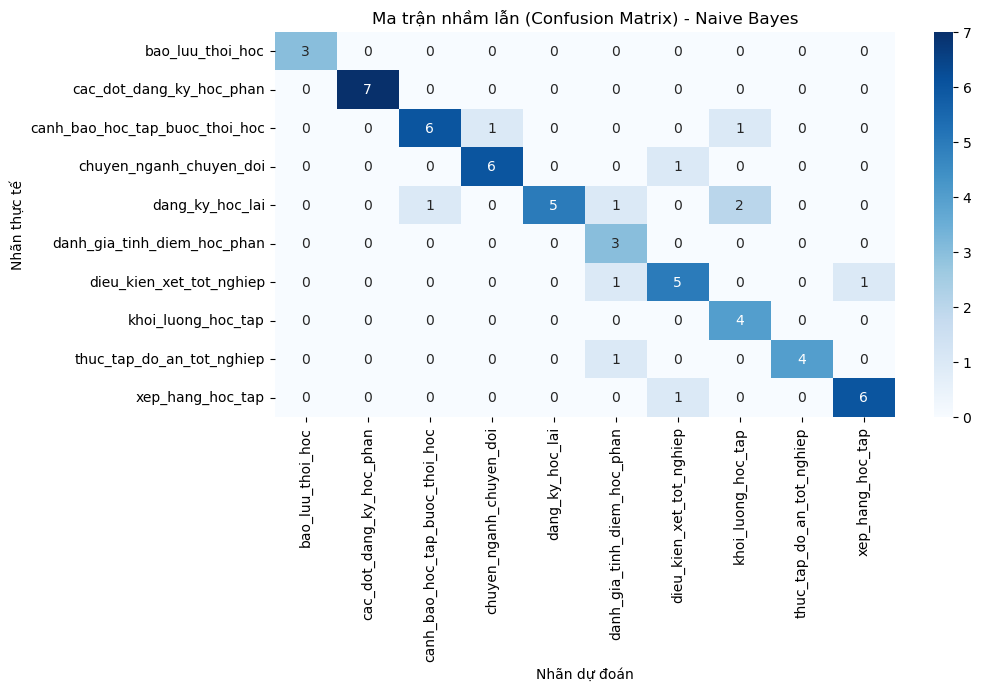

In [14]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Vẽ Ma trận nhầm lẫn (Confusion Matrix) để xem bot hay nhầm câu nào
cm_nb = confusion_matrix(y_test, y_pred_nb)
plt.figure(figsize=(10, 5))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues', 
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.title('Ma trận nhầm lẫn (Confusion Matrix) - Naive Bayes')
plt.ylabel('Nhãn thực tế')
plt.xlabel('Nhãn dự đoán')
plt.savefig('confusion_matrix_nb.png')

#### Đánh giá tổng quan: 
- Đường chéo chính (Màu xanh đậm): Các ô nằm trên đường chéo từ góc trên trái xuống góc dưới phải thể hiện số lần dự đoán ĐÚNG. Nhìn chung, đường chéo này có màu đậm nhất, chứng tỏ mô hình hoạt động khá ổn định (khoảng trên 80%).
- Các ô ngoài đường chéo (Màu nhạt/Trắng): Thể hiện những lần dự đoán SAI. Có một số điểm nhầm lẫn đáng chú ý cần khắc phục.

#### Phân tích theo từng nhóm:

Những chủ đề (Intent) mà mô hình nhận diện khá chuẩn, hầu như không sai sót:

cac_dot_dang_ky_hoc_phan:

- Thực tế: 7 câu.

- Đoán đúng: 7/7 (100%).

bao_luu_thoi_hoc:

- Thực tế: 3 câu.

- Đoán đúng: 3/3 (100%).

- Lưu ý: Tuy nhiên, nó lại bị các nhóm khác nhận nhầm sang 1 lần.

Nhóm cần cải thiện: 

Chủ đề dang_ky_hoc_lai (Đăng ký học lại)

- Vấn đề: Thực tế có 9 câu, chỉ đúng 6.

- Nhầm sang: khoi_luong_hoc_tap (2 lần), danh_gia_tinh_diem... (1 lần).

- Phân tích nguyên nhân: Có thể trong câu hỏi học lại có chứa từ "tín chỉ" hoặc "điểm" (ví dụ: "điểm thấp có phải học lại không?"). Vì Naive Bayes đếm từ, nên nó thấy chữ "điểm" thì nghĩ là danh_gia_tinh_diem, thấy "tín chỉ" thì nghĩ là khoi_luong.

Chủ đề canh_bao_hoc_tap_buoc_thoi_hoc (Cảnh báo/Buộc thôi học)

- Vấn đề: Đây là chủ đề bị phân tán dữ liệu nhiều nhất (đúng 5/8).

- Nhầm sang:

    - bao_luu_thoi_hoc (1 lần): Dễ hiểu vì cùng có từ "thôi học", "nghỉ học".

    - chuyen_nganh... (1 lần).

    - khoi_luong_hoc_tap (1 lần).

Chủ đề dieu_kien_xet_tot_nghiep

- Vấn đề: Đúng 5/7.

- Nhầm sang: danh_gia_tinh_diem... (1 lần) và xep_hang_hoc_tap (1 lần).

- Phân tích: Các chủ đề này đều liên quan nặng đến "điểm số" (GPA, điểm tổng kết). Máy đang bị loạn giữa các loại điểm.

### Giới thiệu về TP, FP, FN
1. TP (True Positive) có thể hiểu là số lần Bot đoán đúng so với thực tế.
    - TP = 5. Đây là con số nằm ngay trên đường chéo chính màu đậm, tại giao điểm của hàng dang_ky_hoc_lai và cột dang_ky_hoc_lai.
    - Có 5 câu hỏi thực tế là về "Học lại" và Bot đã đoán đúng là "Học lại".

2. FN (False Negative) là số lần Bot đoán sai
    - Nhìn vào Hàng Ngang của dang_ky_hoc_lai. Ngoài số 5 (đúng) ra, ta thấy còn có số 1 (ở cột danh_gia_tinh_diem và canh_bao_hoc_tap) và số 2 (ở cột khoi_luong_hoc_tap).
    - Tổng FN = 1 + 1 + 2 = 4.
=>
    - Có 4 câu hỏi thực tế là "Học lại", nhưng Bot đã bỏ sót.
    - Cụ thể: 1 câu bị Bot đoán nhầm sang "Tính điểm", 1 câu sang "Cảnh báo học tập", 2 câu bị đoán nhầm sang "Khối lượng học tập".

3. FP (False Positive) là Bot nghĩ mình là đúng nhưng thực tế là sai
    - Nhìn vào Cột Dọc của dang_ky_hoc_lai. Ngoài số 5 (đúng) ra, ta nhìn dọc lên trên và xuống dưới xem có số nào khác không.
    - Trong ảnh, cột này toàn số 0.
    - Tổng FP = 0. Chứng tỏ không có câu hỏi nào của chủ đề khác bị Bot đoán nhầm thành "Học lại".

### Precision

Precision (Độ chính xác) là tỷ lệ số điểm True Positive (TP) trong số những điểm được phân loại là Positive (TP+FP). Như vậy Precision càng cao, độ chính xác trong kết luận của mô hình càng cao



In [15]:
from sklearn.metrics import precision_score

# Tính Precision (Độ chính xác dự đoán)
# Lưu ý: Phải thêm average='weighted' vì đây là bài toán nhiều lớp (Multi-class)
prec_nb = precision_score(y_test, y_pred_nb, average='weighted')

print(f"Độ chính xác dự đoán (Precision): {prec_nb*100:.2f}%")

Độ chính xác dự đoán (Precision): 86.07%


### Recall

Recall (Độ bao phủ) được định nghĩa tỷ lệ số điểm True Positive (TP) trong tổng số Positive thực sự (TP+FN). Như vậy Recall càng cao thì mô hình quét càng nhạy, không để sót bất kì trường hợp nào

In [16]:
from sklearn.metrics import recall_score

# Tính Recall (Độ bao phủ)
# average='weighted': Tính trung bình có trọng số cho bài toán nhiều lớp
rec_nb = recall_score(y_test, y_pred_nb, average='weighted')

print(f"Độ bao phủ (Recall): {rec_nb*100:.2f}%")

Độ bao phủ (Recall): 81.67%


### F1 - Score

Nếu chỉ dùng Precision, mô hình chỉ đưa ra dự đoán cho một điểm mà nó chắc chắn nhất. Khi đó
Precision = 1, tuy nhiên ta không thể nói là mô hình này tốt.

Nếu chỉ dùng Recall, nếu mô hình dự đoán tất cả các điểm đều là positive. Khi đó Recall = 1, tuy
nhiên ta cũng không thể nói đây là mô hình tốt.

=> Khi đó F1-score được sử dụng. F1-score là trung bình điều hòa của precision
và recall.

In [17]:
from sklearn.metrics import f1_score

# Tính F1-Score (Trung bình điều hòa giữa Precision và Recall)
# average='weighted': Quan trọng cho bài toán nhiều lớp
f1_nb = f1_score(y_test, y_pred_nb, average='weighted')

print(f"Điểm F1-Score: {f1_nb*100:.2f}%")

Điểm F1-Score: 81.97%


## 6. Cải thiện độ chính xác của mô hình

Dựa qua các đánh giá về độ chính xác, ta có thể cải thiện độ chính xác của mô hình qua những các sau:

1. Bổ sung Stopwords: Thêm các từ điển vào danh sách stopwords để loại bỏ bớt nhiễu. Nếu không loại bỏ, mô hình Naive Bayes (vốn dựa trên xác suất) sẽ gây sai số lớn.

2. Tăng cường từ khóa đặc trưng: Đây là cách trực tiếp nhất để sửa lỗi Recall thấp

    - Với dang_ky_hoc_lai: Thêm nhiều mẫu câu chứa từ "trượt", "rớt môn", "học lại", "cải thiện".

    - Với canh_bao...: Thêm từ "đuổi học", "cảnh cáo", "mức".

3. Thử nghiệm Bigram (Cụm 2 từ):

    - Thay đổi ngram_range=(1, 2) trong TfidfVectorizer.

    - Lý do: Để máy phân biệt được "thôi học" (trong buộc thôi học) và "nghỉ học" (trong bảo lưu). Hiện tại máy đang tách rời các từ này nên dễ nhầm.

Cách 1 và cách 2 đều là cách làm thủ công và phải dựa vào các phản hồi từ người dùng khi Bot trả lời sai nên ta sẽ triển khai ngay phương pháp thứ 3 vì nó khả thi ngay bây giờ

In [18]:
# BƯỚC 1: SỬA VECTORIZER
# ngram_range=(1, 2): Có nghĩa là học cả từ đơn (Unigram) VÀ cụm 2 từ (Bigram)
# Ví dụ: "học máy" -> Máy sẽ học 3 thứ: "học", "máy", "học máy"
vectorizer_bi = TfidfVectorizer(ngram_range=(1, 2))

# BƯỚC 2: SỐ HÓA DỮ LIỆU LẠI TỪ ĐẦU
# Học lại từ vựng mới (bao gồm cả cụm từ)
X_train_bi = vectorizer_bi.fit_transform(X_train)
X_test_bi = vectorizer_bi.transform(X_test)

print(f"Số lượng từ vựng cũ (Unigram): {X_train_vec.shape[1]}") # Biến cũ ở các bước trước
print(f"Số lượng từ vựng mới (Bigram): {X_train_bi.shape[1]}")  # Biến mới

Số lượng từ vựng cũ (Unigram): 312
Số lượng từ vựng mới (Bigram): 1119


In [19]:
# BƯỚC 3: HUẤN LUYỆN LẠI MODEL
model_bi = MultinomialNB()
model_bi.fit(X_train_bi, y_train)

MultinomialNB()

In [20]:
##BƯỚC 4: ĐÁNH GIÁ KẾT QUẢ MỚI
y_pred_bi = model_bi.predict(X_test_bi)

#Độ chính xác cũ:
print(f"Độ chính xác cũ (Unigram): {acc_nb*100:.2f}%")

acc_bi = accuracy_score(y_test, y_pred_bi)
print(f"Độ chính xác (sau khi áp dụng Bigram): {acc_bi*100:.2f}%")



Độ chính xác cũ (Unigram): 81.67%
Độ chính xác (sau khi áp dụng Bigram): 85.00%


Vậy là phương pháp Bigram có hiệu quả và giúp tăng độ chính xác

## 7. Demo nhanh

In [21]:
# Tạo từ điển response_map từ biến raw_data
response_map = {
    intent['tag']: intent['responses'] for intent in raw_data['intents']
}
# Với mỖI mục (intent) nằm trong danh sách dữ liệu gốc (raw_data['intents']), ta lấy tag làm tên mục lục, và lấy responses làm nội dung."

# NHẬP INPUT ĐỂ TEST
input_text = "Bot ăn cơm chưa"  

#XỬ LÝ 

# Bước 1: Gọi hàm pipline để xử lý input
processed_input = processing_pipeline(input_text)
# Biến đổi chữ thành số (Vectorize)
input_vec = vectorizer_bi.transform([processed_input])

# Bước 2: Dự đoán Intent
pred_intent = model_bi.predict(input_vec)[0]

# Bước 3: Lấy câu trả lời
if pred_intent in response_map:
    # Lấy phần tử đầu tiên [0] trong list câu trả lời
    response_text = response_map[pred_intent][0]
else:
    response_text = "Xin lỗi, bot chưa học câu này."

# 4. IN KẾT QUẢ RA MÀN HÌNH

print(f"INPUT (Người dùng nhập):  {input_text}")
print(f"DỮ LIỆU ĐƯỢC ĐƯA VÀO MÁY:  {processed_input}")
print("-" * 60)
print(f"INTENT (Dự đoán):         [{pred_intent}]")
print(f"RESPONSE (Bot trả lời):    {response_text}")

INPUT (Người dùng nhập):  Bot ăn cơm chưa
DỮ LIỆU ĐƯỢC ĐƯA VÀO MÁY:  bot ăn cơm chưa
------------------------------------------------------------
INTENT (Dự đoán):         [thuc_tap_do_an_tot_nghiep]
RESPONSE (Bot trả lời):    (Điều 26 & 27) Quy định thực tập và đồ án tốt nghiệp: 
- Điều kiện đi thực tập tốt nghiệp (doanh nghiệp): Hoàn thành hầu hết học phần (trừ đồ án tốt nghiệp) hoặc còn nợ tối đa 2 học phần chưa đạt yêu cầu và có điểm TBC tích lũy toàn khóa đạt từ 2,0 điểm trở lên. 
- Đăng ký và Hướng dẫn: Đăng ký theo kế hoạch ngành/chuyên ngành. Mỗi sinh viên có giảng viên hướng dẫn khoa học, có thể thêm người hướng dẫn tại cơ sở thực tập. 
- Đánh giá: Điểm TTTN/TTDN: Điểm quá trình do giảng viên hướng dẫn dựa trên nhận xét cơ sở thực tập; điểm cuối kỳ là điểm chấm bảo vệ do ít nhất 2 giảng viên thực hiện. Điểm của người hướng dẫn hoặc điểm bảo vệ dưới 5 đều được coi là điểm F và sinh viên phải đăng ký lại. 
- Thủ tục: Phòng ĐTĐH xét và công bố danh sách sinh viên đủ điều kiện nhậ

### Vấn đề gặp phải trong thực tế
Theo như đoạn demo trên, ta đã gặp phải trường hợp "False Positive" (Dương tính giả) trong thực tế

Nguyên nhân:
- Từ lạ: Từ "Bot ăn cơm chưa" không có trong tập dữ liệu huấn luyện (JSON) của các Intent hiện tại. Khi vectorizer gặp từ lạ, nó lờ đi hoặc tạo ra vector rỗng/gần rỗng.

- Cơ chế Naive Bayes: Khi gặp input lạ hoặc không rõ ràng, thuật toán thường có xu hướng "đoán bừa" vào cái nhãn (intent) nào có số lượng câu mẫu nhiều nhất trong tập Train (hoặc nhãn có xác suất tiên nghiệm cao nhất). Có vẻ như nhãn thuc_tap_do_an_tot_nghiep đang chiếm ưu thế.

### Cách khắc phục
Lọc bỏ câu có độ tin cậy thấp:
- Đây là cách quan trọng nhất để chặn các câu nhập linh tinh (ví dụ: "dghdfg", "ăn cơm chưa",...).

- Thay vì dùng model.predict() (chỉ trả về nhãn), ta dùng model.predict_proba() (trả về xác suất % của từng nhãn). Nếu xác suất cao nhất mà vẫn thấp (ví dụ dưới 20% hoặc 10%), ta coi như Bot không hiểu.

In [22]:
# CẤU HÌNH NGƯỠNG TIN CẬY
THRESHOLD = 0.15
# Nếu dưới 15%: Không rõ -> Xin lỗi, yêu cầu người dùng nhập lại

# NHẬP INPUT ĐỂ TEST
input_text = "Bot ăn cơm chưa" 

# XỬ LÝ 

# Bước 1: Gọi hàm pipeline để xử lý input
processed_input = processing_pipeline(input_text)
# Biến đổi chữ thành số (Vectorize)
input_vec = vectorizer_bi.transform([processed_input])

# BƯỚC QUAN TRỌNG: TÍNH XÁC SUẤT
# Thay vì chỉ predict, ta lấy xác suất (probability)
probs = model_bi.predict_proba(input_vec)[0] # Lấy danh sách % của tất cả các nhãn
max_prob = max(probs)                        # Lấy con số % cao nhất
pred_index = probs.argmax()                  # Lấy vị trí của nhãn cao nhất
pred_intent = model_bi.classes_[pred_index]  # Lấy tên nhãn (tag)


# Bước 3: Chọn câu trả lời dựa trên độ tin cậy
if max_prob > THRESHOLD: #Threshold = 0.15
    # Trường hợp 1: >15%
    if pred_intent in response_map:
        response_text = response_map[pred_intent][0]
    else:
        response_text = "Xin lỗi, mình gặp lỗi dữ liệu (có nhãn nhưng không có câu trả lời)."
else:
    # Trường hợp 2: Không rõ (<15%)
    response_text = "Xin lỗi, câu này mình chưa được học hoặc bạn nhập chưa rõ nghĩa."

# 4. IN KẾT QUẢ RA MÀN HÌNH
print(f"INPUT:            {input_text}")
print(f"DỮ LIỆU ĐƯỢC ĐƯA VÀO MÁY:     {processed_input}")
print("-" * 60)
print(f"INTENT (Dự đoán): [{pred_intent}]")
print(f"ĐỘ TIN CẬY:       {max_prob*100:.2f}%")
print("-" * 60)
print(f"RESPONSE:         {response_text}")

INPUT:            Bot ăn cơm chưa
DỮ LIỆU ĐƯỢC ĐƯA VÀO MÁY:     bot ăn cơm chưa
------------------------------------------------------------
INTENT (Dự đoán): [thuc_tap_do_an_tot_nghiep]
ĐỘ TIN CẬY:       13.36%
------------------------------------------------------------
RESPONSE:         Xin lỗi, câu này mình chưa được học hoặc bạn nhập chưa rõ nghĩa.


Cách này cũng chỉ là tương đối để xử lý các câu hỏi rác. Hi vọng trong tương lai nhóm sẽ tìm ra được nhiều cách khắc phục phù hợp hơn.

### Đóng gói model đã huấn luyện để chuẩn bị cho phần triển khai giao diện người dùng lên web

In [23]:
import joblib
# Đóng gói 3 thứ quan trọng nhất vào 1 file:
# 1. Model Bigram (Bộ não)
# 2. Vectorizer Bigram (Bộ dịch)
# 3. Response Map (Bộ câu trả lời)
data_to_save = {
    "model": model_bi,              # Model
    "vectorizer": vectorizer_bi,    # Vectorizer tương ứng
    "response_map": response_map    # Từ điển câu trả lời
}

# Lưu vào file
with open("chatbot_data.pkl", "wb") as f:
    joblib.dump(data_to_save, f)

print("Đã lưu model thành công vào file chatbot_data.pkl")

Đã lưu model thành công vào file chatbot_data.pkl
